Assignment 9
Name: Shlok Nikam
PRN: 12414145
Batch: 2
Division: D
Branch: CSE(AI)


9.Write a program to do following:

This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.

Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.
      Data Set: https://www.kaggle.com/shwetabh123/mall-customers




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

Import Dataset and Libraries


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Outlier visualization for Annual Income and Spending Score

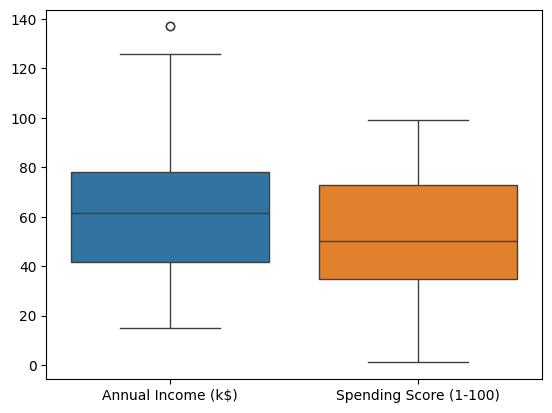

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df[['Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

In [ ]:
Q1 = df[['Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.25)
Q3 = df[['Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[['Annual Income (k$)', 'Spending Score (1-100)']] < (Q1 - 1.5 * IQR)) |
                (df[['Annual Income (k$)', 'Spending Score (1-100)']] > (Q3 + 1.5 * IQR))).any(axis=1)]

df_clean.shape

(198, 5)

Boxplot after Outlier Removal

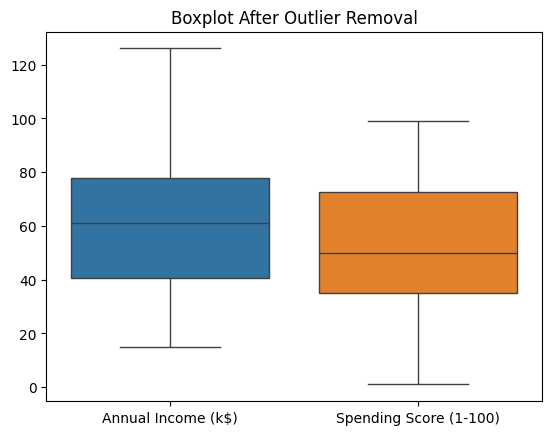

In [ ]:
sns.boxplot(data=df_clean[['Annual Income (k$)', 'Spending Score (1-100)']])
plt.title("Boxplot After Outlier Removal")
plt.show()

In [ ]:
X = df_clean.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Feature selection

In [ ]:
X = df_clean.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_train, test_size=0.2, random_state=42)

Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X)

WCSS Calculation

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

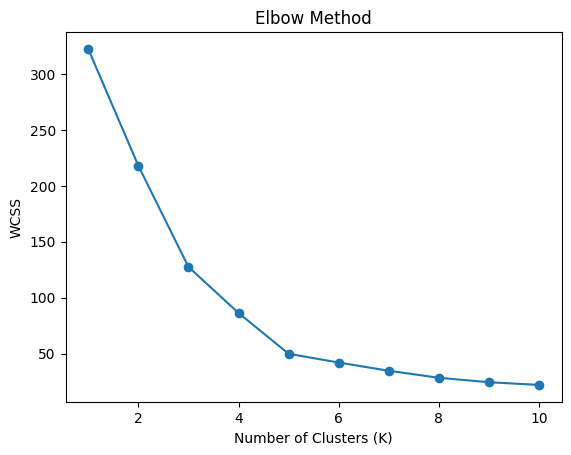

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_train)

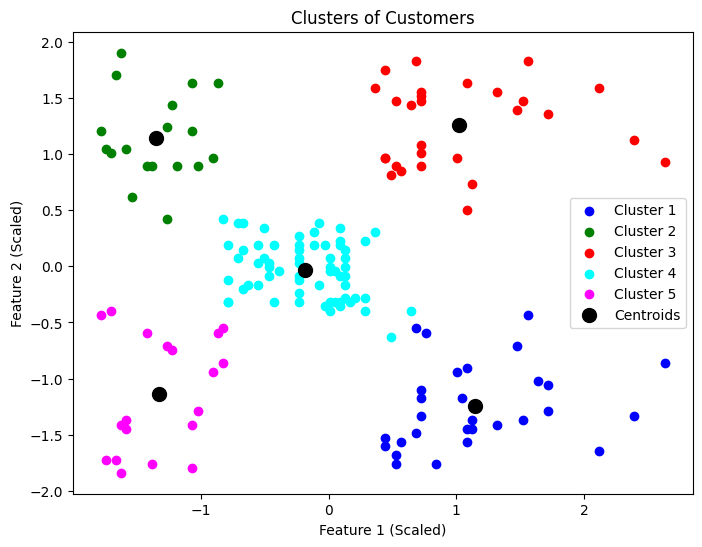

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_train[labels == 0, 0], X_train[labels == 0, 1], c='blue', label='Cluster 1')
plt.scatter(X_train[labels == 1, 0], X_train[labels == 1, 1], c='green', label='Cluster 2')
plt.scatter(X_train[labels == 2, 0], X_train[labels == 2, 1], c='red', label='Cluster 3')
plt.scatter(X_train[labels == 3, 0], X_train[labels == 3, 1], c='cyan', label='Cluster 4')
plt.scatter(X_train[labels == 4, 0], X_train[labels == 4, 1], c='magenta', label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='black', label='Centroids')

plt.title('Clusters of Customers')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.show()

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_train, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5586469871484757
